<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/dp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1- Introduction + Set-up


In [52]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [53]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [54]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [56]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# 2- EDA

In [57]:

# check the folder strucutre
import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")


TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


**Note**
Dataset is already imnalanced, we have to shuffle and balance it...

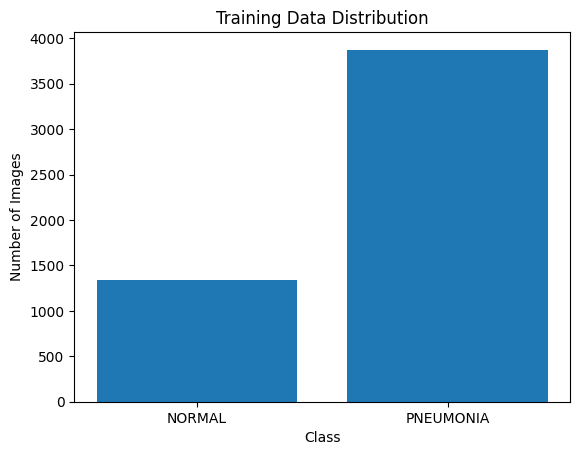

In [58]:
# visulize that
import matplotlib.pyplot as plt

train_counts = {'NORMAL': 1341, 'PNEUMONIA': 3875}

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## 2-2 Show sample images

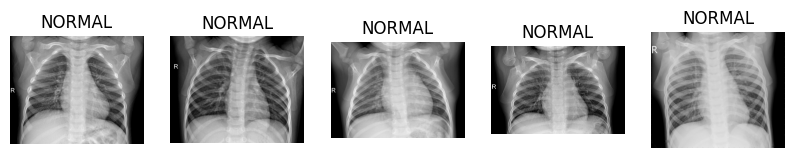

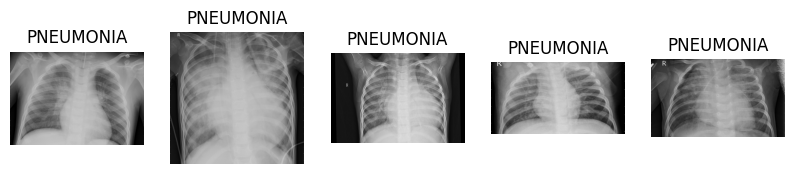

In [59]:
# show some sample images

import matplotlib.pyplot as plt
import cv2
import os

def show_samples(base_path, split, label):
    path = os.path.join(base_path, split, label)
    images = os.listdir(path)[:5]  # show 5 images

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.show()

show_samples(base_path, 'train', 'NORMAL')
show_samples(base_path, 'train', 'PNEUMONIA')

**Note**  
Images are clear, mostly, and some of them do not have the same size

##  2-3 Check image sizes (CRUCIAL before model)

In [60]:
sizes = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:100]:  # sample 100
        img = cv2.imread(os.path.join(path, img_name))
        sizes.append(img.shape)

print(set(sizes))

{(1318, 1778, 3), (864, 1408, 3), (1341, 1754, 3), (1310, 1782, 3), (1380, 1858, 3), (1012, 1496, 3), (1171, 1472, 3), (1434, 1810, 3), (1190, 1492, 3), (1248, 1588, 3), (1296, 1738, 3), (1093, 1362, 3), (1136, 1632, 3), (1604, 1986, 3), (1248, 1724, 3), (959, 1298, 3), (1109, 1522, 3), (792, 1136, 3), (568, 1112, 3), (1080, 1633, 3), (576, 1016, 3), (1056, 1560, 3), (648, 896, 3), (488, 840, 3), (672, 1208, 3), (1017, 1272, 3), (616, 848, 3), (1573, 1844, 3), (568, 1008, 3), (688, 1000, 3), (544, 1000, 3), (1252, 1666, 3), (544, 976, 3), (1208, 1632, 3), (1072, 1416, 3), (688, 1136, 3), (720, 1144, 3), (1059, 1442, 3), (752, 1144, 3), (1619, 1728, 3), (1175, 1620, 3), (1201, 1496, 3), (992, 1408, 3), (560, 850, 3), (1364, 1654, 3), (824, 1200, 3), (1399, 1762, 3), (863, 1098, 3), (1136, 1230, 3), (1298, 1696, 3), (842, 1064, 3), (998, 1562, 3), (864, 1232, 3), (1176, 1416, 3), (1171, 1666, 3), (1634, 1956, 3), (576, 968, 3), (1310, 1434, 3), (1743, 1932, 3), (1279, 1638, 3), (1059, 12

**Note** as we can clrearly see now, they absolutely DO NOT have a unified size, so we have to consifer this

## 2-4 Pixel distribution (advanced but powerful)

**WARNING** System will crash before running this:

In [ ]:
import numpy as np
import os

pixels = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:50]:
        img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
        pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

**Note** Skipping Pixel Distrubution due to not enough RAM

# DAY 4
Proper Split,
Preprocessing,
Normalization

The issues that we have we have right now are:

TRAIN: ok but imbalanced

VAL: too small ❌

TEST: keep it untouched ✅

## 1- Train / Validation Split

## Handle Imbalance

✔ EDA
✔ Split (you just did this)
✔ Class weights (you just did this)
⬜ Preprocessing (next)
⬜ Model

**Note** Stratified Split garuntees that the dataset is trustworthy

Splitting → makes evaluation fair

Class weights → makes learning fair

✔ EDA

✔ Proper split (huge step)

✔ Understand imbalance

⬜ Preprocessing (next)

⬜ Training

Check old data

In [61]:
import os
from collections import Counter

base_path = "chest_xray"

def count_split(split):
    counts = {}
    for label in os.listdir(os.path.join(base_path, split)):
        path = os.path.join(base_path, split, label)
        counts[label] = len(os.listdir(path))
    return counts

print("ORIGINAL TRAIN:", count_split("train"))
print("ORIGINAL VAL:", count_split("val"))
print("ORIGINAL TEST:", count_split("test"))

ORIGINAL TRAIN: {'NORMAL': 1341, 'PNEUMONIA': 3875}
ORIGINAL VAL: {'NORMAL': 8, 'PNEUMONIA': 8}
ORIGINAL TEST: {'NORMAL': 234, 'PNEUMONIA': 390}


Check new data (memory)

## Prprocessing

In [62]:
# ================================
# 🧠 IMPORTS
# ================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [63]:
# ================================
# ⚙️ PREPROCESSING PIPELINE
# ================================

# Training generator (includes normalization + augmentation later if needed)
train_datagen = ImageDataGenerator(
    rescale=1./255   # 🔥 normalize pixels (0–255 → 0–1)
)

# Validation generator (ONLY normalization)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [64]:
# ================================
# 📊 LOAD DATA (WITH SPLIT BUILT-IN)
# ================================

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",   # original train folder
    target_size=(64, 64),  # 🔥 resize all images
    batch_size=32,
    class_mode='binary',
    subset=None   # we will not use built-in split here
)

Found 5216 images belonging to 2 classes.


In [65]:
# ================================
# 📊 TRAIN + VAL SPLIT INSIDE GENERATOR
# ================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 🔥 80/20 split
)

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'   # 🔥 training part
)

val_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # 🔥 validation part
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [66]:
# NEW

# Now we do all of these new steps instead
# ADD THIS as a new cell right after ↑
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_array = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)
print("Class mapping:", train_generator.class_indices)

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


**Note**
what happend?
✔ Split data (again, but properly)
✔ Resize images (224x224)
✔ Normalize pixels (0–1)
✔ Load in batches (no RAM crash)
✔ Shuffle automatically

**Note** We want to resize to (112, 112) to make the images smaller

In [74]:
# ================================
# 🧪 TEST GENERATOR
# ================================

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # ❗ important for evaluation
)

Found 624 images belonging to 2 classes.


In [75]:
# Get a batch (images + labels)
images, labels = next(test_generator)

In [76]:
print(images.shape)

(32, 64, 64, 3)


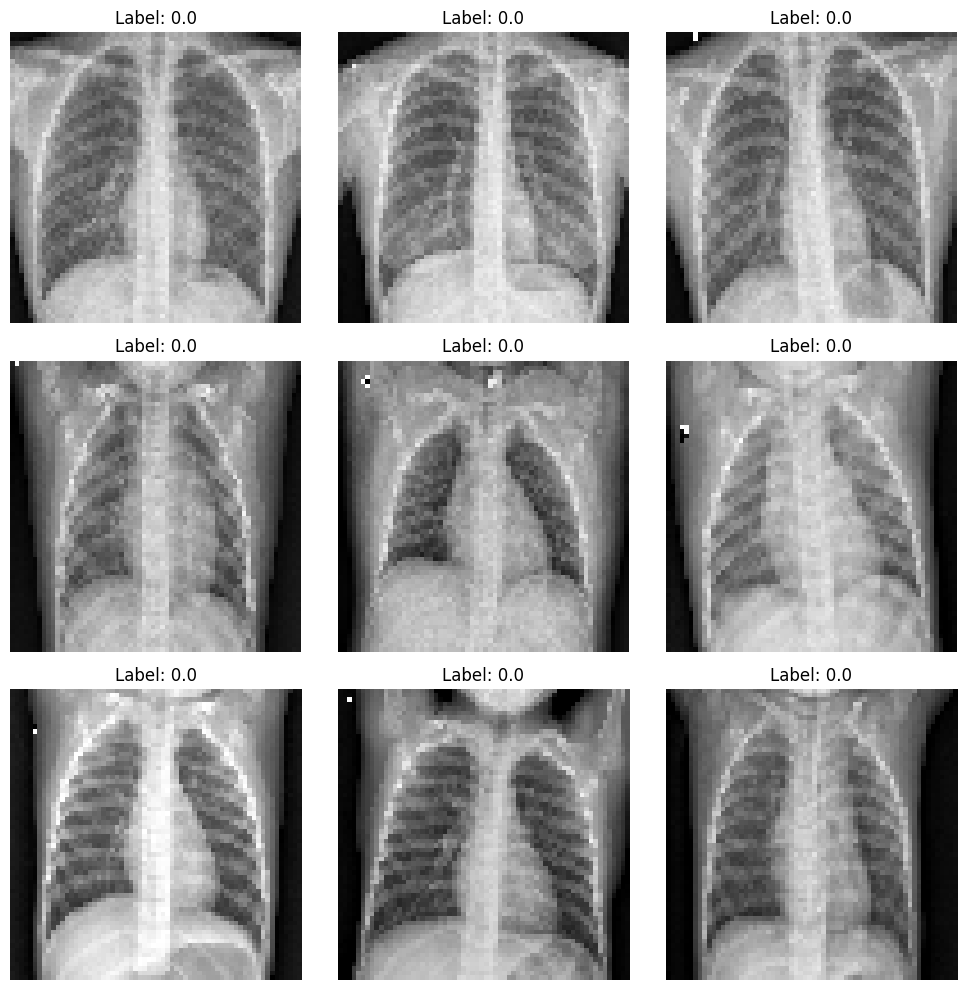

In [77]:
import matplotlib.pyplot as plt

# Get a batch
images, labels = next(test_generator)

# Show first 9 images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Fitting and Training

## 1- first model ANN

In [78]:
# using keras
import tensorflow as tf
from tensorflow import keras

In [89]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[64, 64, 3]),

    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.3),    # randomly dropout 30%

    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.3),    # randomly dropout 30%

    keras.layers.Dense(1, activation="sigmoid") # best for binary classification
])

In [90]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │     3,686,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,716,901 (14.18 MB)

 Trainable params: 3,716,901 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

**NOTES**
- lots of parameters, we expect overfitting of course.
- we might need to do dropping and l1/l2

In [91]:
# let us try to train the model without any reglization
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


**NOTES**
- binary_crossentropy as the loss function, the name is self explanotary
- adam is really good for binary classification
- We might wanna adjust the learning rate


In [92]:
# fitting the model
history = model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights_dict)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 274ms/step - accuracy: 0.7196 - loss: 0.8258 - val_accuracy: 0.8686 - val_loss: 0.3057
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 262ms/step - accuracy: 0.8569 - loss: 0.3212 - val_accuracy: 0.9214 - val_loss: 0.2340
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.8867 - loss: 0.2716 - val_accuracy: 0.7872 - val_loss: 0.4650
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 35s 267ms/step - accuracy: 0.8912 - loss: 0.2771 - val_accuracy: 0.9214 - val_loss: 0.1906
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 35s 265ms/step - accuracy: 0.8982 - loss: 0.2869 - val_accuracy: 0.9175 - val_loss: 0.1959
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.8879 - loss: 0.3319 - val_accuracy: 0.8888 - val_loss: 0.2692
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.9113 - loss: 0.2621 - val_accuracy: 0.8418 - val_loss: 0.3807
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.9123 - loss: 0

**Note** clear overfitting, time for the graphs

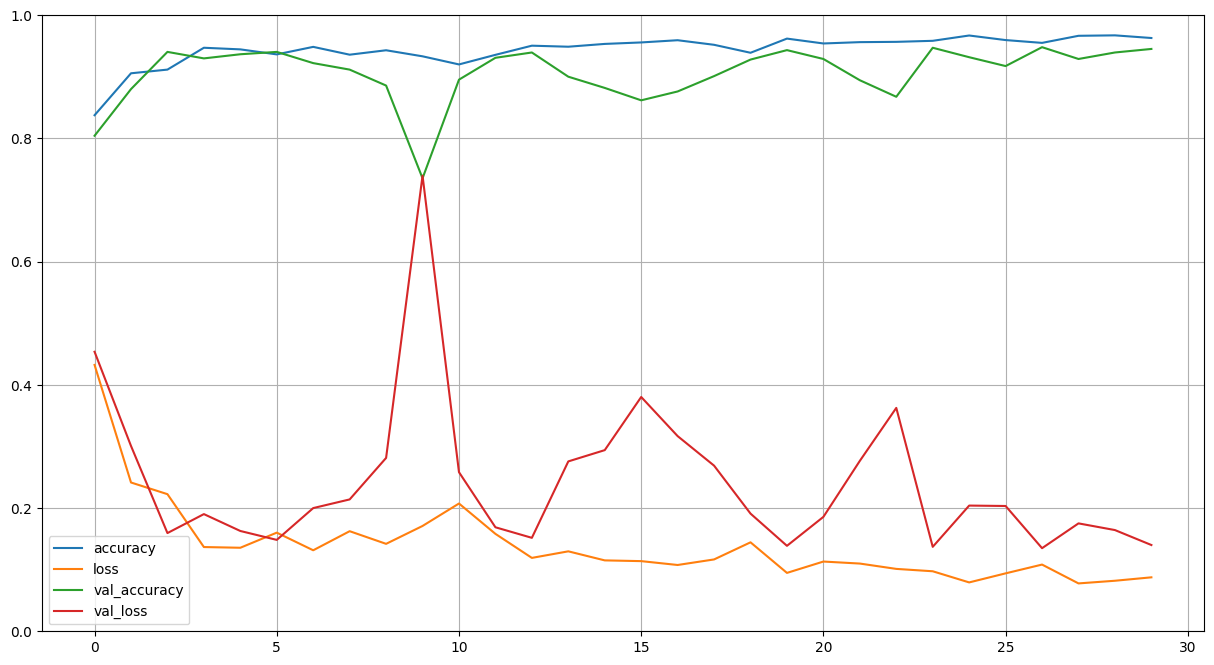

In [87]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

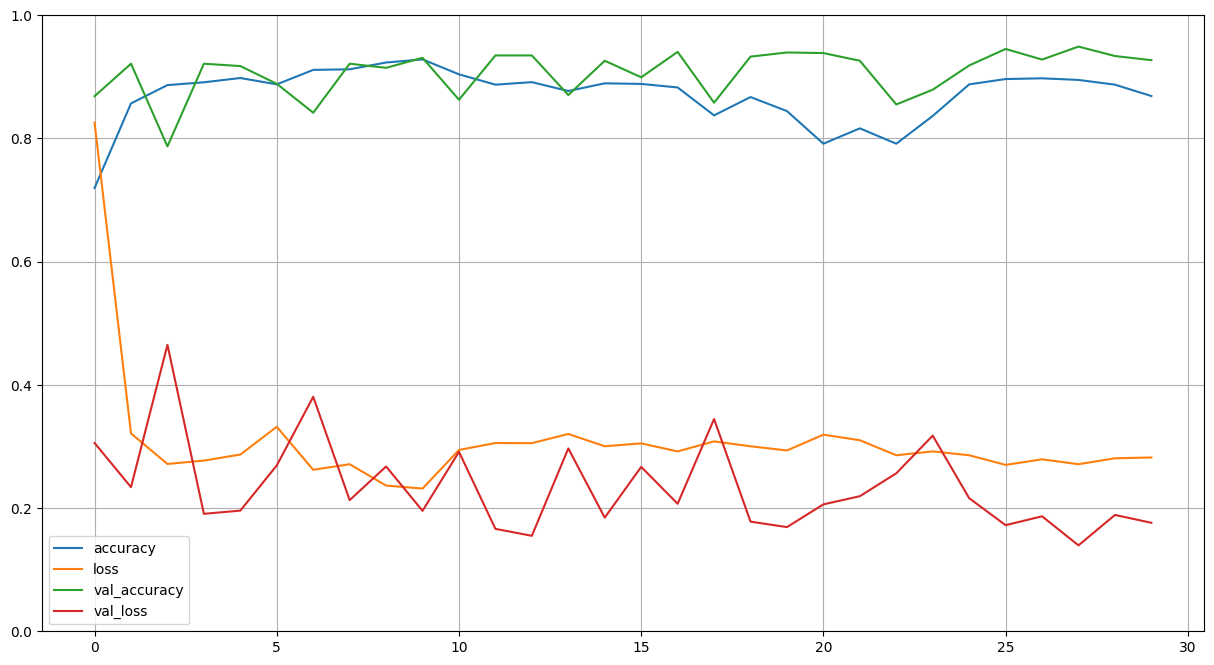

In [93]:
# after dropout
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Note**
- Signs of underfitting this time around, let us bring the drop out rate down a notch